# Challenge 1 - Tic Tac Toe

In this lab you will perform deep learning analysis on a dataset of playing [Tic Tac Toe](https://en.wikipedia.org/wiki/Tic-tac-toe).

There are 9 grids in Tic Tac Toe that are coded as the following picture shows:

![Tic Tac Toe Grids](tttboard.jpg)

In the first 9 columns of the dataset you can find which marks (`x` or `o`) exist in the grids. If there is no mark in a certain grid, it is labeled as `b`. The last column is `class` which tells you whether Player X (who always moves first in Tic Tac Toe) wins in this configuration. Note that when `class` has the value `False`, it means either Player O wins the game or it ends up as a draw.

Follow the steps suggested below to conduct a neural network analysis using Tensorflow and Keras. You will build a deep learning model to predict whether Player X wins the game or not.

## Step 1: Data Engineering

This dataset is almost in the ready-to-use state so you do not need to worry about missing values and so on. Still, some simple data engineering is needed.

1. Read `tic-tac-toe.csv` into a dataframe.
1. Inspect the dataset. Determine if the dataset is reliable by eyeballing the data.
1. Convert the categorical values to numeric in all columns.
1. Separate the inputs and output.
1. Normalize the input data.

In [120]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
import tensorflow as tf
import sklearn as sk



In [121]:
# Load the dataset
df= pd.read_csv ("tic-tac-toe.csv")

# Display the first few rows of the dataset
print(df.head())

  TL TM TR ML MM MR BL BM BR  class
0  x  x  x  x  o  o  x  o  o   True
1  x  x  x  x  o  o  o  x  o   True
2  x  x  x  x  o  o  o  o  x   True
3  x  x  x  x  o  o  o  b  b   True
4  x  x  x  x  o  o  b  o  b   True


In [122]:
#get the shape of the dataset
print(df.shape)

(958, 10)


In [123]:
X = df.drop('class', axis=1)
y = df['class']

## Step 2: Build Neural Network

To build the neural network, you can refer to your own codes you wrote while following the [Deep Learning with Python, TensorFlow, and Keras tutorial](https://www.youtube.com/watch?v=wQ8BIBpya2k) in the lesson. It's pretty similar to what you will be doing in this lab.

1. Split the training and test data.
1. Create a `Sequential` model.
1. Add several layers to your model. Make sure you use ReLU as the activation function for the middle layers. Use Softmax for the output layer because each output has a single lable and all the label probabilities add up to 1.
1. Compile the model using `adam` as the optimizer and `sparse_categorical_crossentropy` as the loss function. For metrics, use `accuracy` for now.
1. Fit the training data.
1. Evaluate your neural network model with the test data.
1. Save your model as `tic-tac-toe.model`.

In [124]:
# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [125]:
# Encode the categorical variables
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for column in X_train.columns:
    X_train[column] = le.fit_transform(X_train[column])
new_X_train = X_train
new_X_train.head()



,TL,TM,TR,ML,MM,MR,BL,BM,BR
302,1,2,2,1,2,1,0,2,0
467,1,0,1,1,2,0,2,2,2
294,2,0,0,0,2,0,1,1,2
548,0,1,2,1,0,2,0,0,2
465,1,0,1,2,1,0,2,2,2


In [126]:
#Encode the categorical variables
for column in X_test.columns:
    X_test[column] = le.transform(X_test[column])
new_X_test = X_test
new_X_test.head()

,TL,TM,TR,ML,MM,MR,BL,BM,BR
836,1,1,1,0,2,2,2,1,2
477,1,0,0,2,2,2,0,0,1
350,1,2,0,2,2,0,1,2,1
891,0,2,1,2,2,1,2,1,1
855,1,0,2,2,1,0,0,2,1


In [127]:
# Normalize the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
new_X_train = scaler.fit_transform(X_train)
new_X_test = scaler.transform(X_test)
new_X_train[:5]

array([[-0.31404892,  1.0937831 ,  1.00334948, -0.19957299,  0.93075284,
        -0.17543104, -1.55368271,  1.06506141, -1.5666366 ],
       [-0.31404892, -1.4451195 , -0.29490339, -0.19957299,  0.93075284,
        -1.41969195,  1.01123314,  1.06506141,  1.00856433],
       [ 1.00049465, -1.4451195 , -1.59315627, -1.46298544,  0.93075284,
        -1.41969195, -0.27122478, -0.18814449,  1.00856433],
       [-1.62859249, -0.1756682 ,  1.00334948, -0.19957299, -1.75458303,
         1.06882987, -1.55368271, -1.44135039,  1.00856433],
       [-0.31404892, -1.4451195 , -0.29490339,  1.06383947, -0.4119151 ,
        -1.41969195,  1.01123314,  1.06506141,  1.00856433]])

In [128]:
# Build the neural network model
model = Sequential()
model.add(Dense(64, input_dim=new_X_train.shape[1], activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(2, activation='softmax'))

/opt/anaconda3/envs/anaconda-ml-ai/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [129]:
# Compile the model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [130]:
# Train the model
history = model.fit(new_X_train, y_train, epochs=50, batch_size=32,
                    validation_data=(new_X_test, y_test))

Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5862 - loss: 0.6945 - val_accuracy: 0.6719 - val_loss: 0.6288
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6162 - loss: 0.6788 - val_accuracy: 0.6667 - val_loss: 0.6174
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6292 - loss: 0.6586 - val_accuracy: 0.6719 - val_loss: 0.6117
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6397 - loss: 0.6472 - val_accuracy: 0.6615 - val_loss: 0.6071
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6462 - loss: 0.6383 - val_accuracy: 0.6615 - val_loss: 0.6037
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6658 - loss: 0.6350 - val_accuracy: 0.6771 - val_loss: 0.6007
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6462 - loss: 0.6330 - val_accuracy: 0.6615 - val_loss: 0.5953
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6554 - loss: 0.6277 - val_accuracy: 0.6823 - val_loss:

In [131]:
# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}')

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6667 - loss: 0.7854 
Test Loss: 0.7854, Test Accuracy: 0.6667


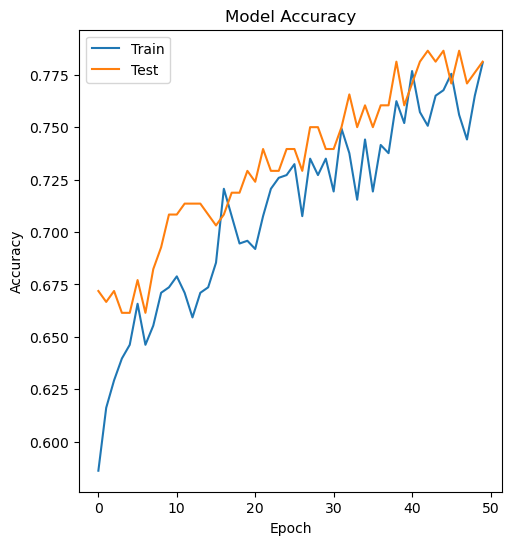

In [132]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

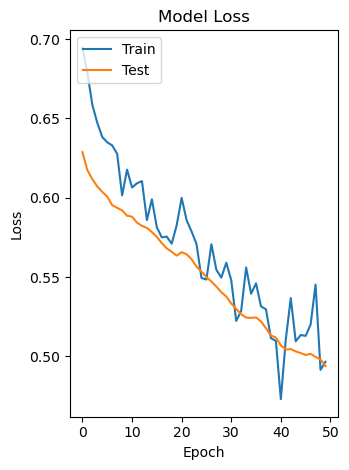

In [133]:
# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.tight_layout()
plt.show()  




## Step 3: Make Predictions

Now load your saved model and use it to make predictions on a few random rows in the test dataset. Check if the predictions are correct.

In [134]:
# predictions on few random rows from the test set
random_indices = np.random.choice(X_test.index, size=5, replace=False)
for idx in random_indices:
    sample = X_test.loc[idx].values.reshape(1, -1)
    sample_scaled = scaler.transform(sample)
    prediction = model.predict(sample_scaled)
    predicted_class = (prediction > 0.5).astype(int)[0][0]
    print(f'Actual: {y_test.loc[idx]}, Predicted: {predicted_class}')   


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Actual: True, Predicted: 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Actual: False, Predicted: 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Actual: True, Predicted: 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Actual: True, Predicted: 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Actual: True, Predicted: 0


/opt/anaconda3/envs/anaconda-ml-ai/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/anaconda-ml-ai/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/anaconda-ml-ai/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/anaconda-ml-ai/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/anaconda-ml-ai/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature nam

## Step 4: Improve Your Model

Did your model achieve low loss (<0.1) and high accuracy (>0.95)? If not, try to improve your model.

But how? There are so many things you can play with in Tensorflow and in the next challenge you'll learn about these things. But in this challenge, let's just do a few things to see if they will help.

* Add more layers to your model. If the data are complex you need more layers. But don't use more layers than you need. If adding more layers does not improve the model performance you don't need additional layers.
* Adjust the learning rate when you compile the model. This means you will create a custom `tf.keras.optimizers.Adam` instance where you specify the learning rate you want. Then pass the instance to `model.compile` as the optimizer.
    * `tf.keras.optimizers.Adam` [reference](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam).
    * Don't worry if you don't understand what the learning rate does. You'll learn about it in the next challenge.
* Adjust the number of epochs when you fit the training data to the model. Your model performance continues to improve as you train more epochs. But eventually it will reach the ceiling and the performance will stay the same.

In [135]:
#improve the model by adding more layers and neurons
model = Sequential()
model.add(Dense(128, input_dim=new_X_train.shape[1], activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(2, activation='softmax'))


/opt/anaconda3/envs/anaconda-ml-ai/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [136]:
# Compile the model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [139]:
# Train the model
history = model.fit(new_X_train, y_train, epochs=100, batch_size=32,
                    validation_data=(new_X_test, y_test))

Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8146 - loss: 0.4277 - val_accuracy: 0.8438 - val_loss: 0.4084
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7977 - loss: 0.4233 - val_accuracy: 0.8438 - val_loss: 0.4011
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8146 - loss: 0.4445 - val_accuracy: 0.8490 - val_loss: 0.4043
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8198 - loss: 0.4049 - val_accuracy: 0.8333 - val_loss: 0.3988
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8225 - loss: 0.3969 - val_accuracy: 0.8594 - val_loss: 0.3912
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8277 - loss: 0.4301 - val_accuracy: 0.8333 - val_loss: 0.3930
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8159 - loss: 0.4055 - val_accuracy: 0.8385 - val_loss: 0.3962
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8264 - loss: 0.3988 - val_accuracy: 0.8490 - v

**Which approach(es) did you find helpful to improve your model performance?**

In [ ]:
# the folowing approachs had been used to improve the model:
# 1. Adding more layers and neurons to the model.
# 2. Increasing the number of epochs to allow the model to learn better.
